In [1]:
import numpy as np
import moments
import demes
import matplotlib.pyplot as plt

In [2]:
b = demes.Builder()
b.add_deme(
    "X",
    epochs=[
        {"start_size": 1e4, "end_time": 1e6},
        {"start_size": 1e5, "end_time": 0}
    ]
)
g = b.resolve()

In [3]:
r = 1e-8
times = np.linspace(0, 1.1e6, 200)
Covs = []
for time in times:
    yy = moments.Demes.LD(
        g, sampled_demes=["X"], u=1e-8, r=r, sample_times=[time])
    DP = yy.H2(0)[0]
    theta2 = yy.H()[0] ** 2
    Cov = (DP - theta2) / theta2
    Covs.append(Cov)
    # print(theta2, DP, Cov)

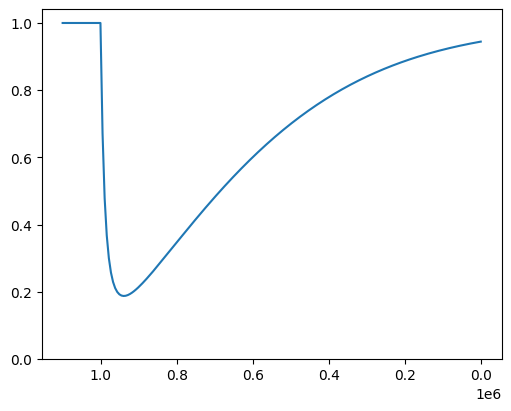

In [4]:
fig, ax = plt.subplots(figsize=(5, 4), layout="constrained")
ax.plot(times, Covs)
ax.set_ylim(0, )
ax.invert_xaxis()

In [5]:
np.min(Covs), np.max(Covs)

(np.float64(0.18778636895937492), np.float64(0.9997334014641687))

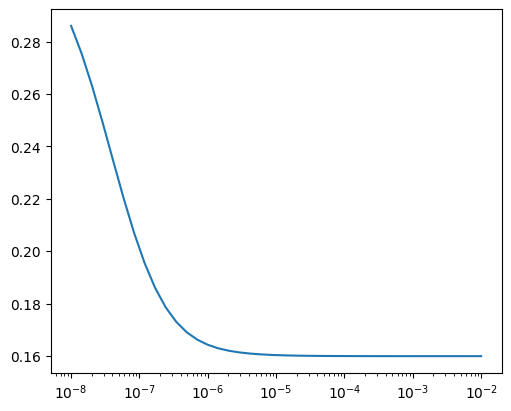

In [6]:
b = demes.Builder()
b.add_deme(
    "X",
    epochs=[
        {"start_size": 1e7, "end_time": 0},
    ]
)
g = b.resolve()
r = np.logspace(-8, -2, 40)
yy = moments.Demes.LD(g, sampled_demes=["X"], u=1e-8, r=r)
fig, ax = plt.subplots(figsize=(5, 4), layout="constrained")
ax.plot(r, yy.H2(0))
ax.set_xscale("log")